<a href="https://colab.research.google.com/github/Allie977/ChamaGuard/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### MY GNN PROJECT [ChamaGuard]
**CRISP-DM STRUCTURED NOTEBOOK**
### Author : Alyssa Njoroge | April 2026

#PHASE I: BUSINESS UNDERSTANDING:

## 1. PROBLEM STATEMENT

### 1.1 Background

In Kenya, chamas (informal savings and loan cooperatives) serve as a critical financial lifeline for millions of citizens, particularly women and rural entrepreneurs. These groups operate on a foundation of social trust and collective accountability. Members contribute regularly to a shared pool and can borrow against it, with repayment enforced not by legal contracts but by social pressure, community standing, and peer monitoring.

Traditional credit scoring models, however, treat each loan applicant as an isolated individual. They evaluate factors such as:

    Personal income and savings

    Individual credit history

    Age and demographic profile

This approach ignores the single most predictive factor in chama lending: the borrower's position within their social network.
A borrower who is well-respected, closely monitored by diligent peers, and part of a cohesive group is fundamentally different from a borrower with identical individual characteristics but weak social ties. The former is protected by social collateral; the latter is not.

### 1.2 The Core Problem

    Current chama loan assessment methods fail to capture the social and relational dynamics that actually drive repayment behavior, leading to:

       - Higher-than-necessary default rates (missed social risk signals)

       - Unfair denial of credit to creditworthy individuals in strong chamas

       - Erosion of group trust when models make unexplainable decisions

### 1.3 Problem Statement

This project aims to address the following challenge:

    "How can we improve the accuracy of microloan default prediction in Kenyan chamas by incorporating the social network structure of the borrowing group, while maintaining explainability for non-technical stakeholders?"

Specifically, ChamaGuard will:

    1.Model the chama as a graph, where nodes represent members and edges represent social/financial relationships.

    2.Use Graph Neural Networks (GNNs) to learn how an individual's default risk is influenced by their neighbors' behaviors and the group's collective characteristics.

    3.Provide interpretable predictions that chama leaders and loan officers can understand and trust.

## 2. RESEARCH OBJECTIVES


### OBJECTIVE 1:Data Collection, Cleaning, and Graph Construction

Key Activities:

    Load and validate the synthetic dataset (sacco_loan.xlsx, 5,000+ records, 33 columns).

    Handle missing values in categorical columns (Education_Level, Collateral_Type).

    Cap extreme outliers in financial columns (Monthly_Revenue_KES, Loan_Amount_KES).

    Encode categorical variables (one-hot encoding for nominal, ordinal encoding for ordered categories).

    Infer chama membership using proxy variables (County, Location_Type, Group_Size, Group_Composition, Group_Meetings_Per_Month, Group_Age_Years, Sanction_Strength).

    Construct an undirected graph where:

        Nodes = Individual borrowers (each row in the dataset).

        Edges = Co-membership in the same inferred chama.
                Edge Weights = Calculated based on group cohesion factors (meeting frequency, sanction strength, group age, training sessions).

    Prepare node features (demographic, business, financial) and labels (Loan_Default_Status).

Rationale:
Without a properly constructed graph, the GNN cannot leverage social relationships. The quality of the inferred graph directly impacts model performance.

Deliverable: A clean, encoded dataset and a PyTorch Geometric Data object containing the graph structure.



### OBJECTIVE 2:Exploratory Data Analysis (EDA)

    To perform exploratory data analysis to identify patterns, trends, and anomalies in both individual borrower characteristics and group-level dynamics.

Key Activities:

    Univariate Analysis:

        Distribution of Loan_Default_Status (class balance assessment).

        Distribution of key numerical features (Age, Monthly_Revenue_KES, Savings_Balance_KES).

        Frequency of categorical features (Education_Level, Credit_History, Group_Composition).
        Bivariate Analysis:

    Default rate by Sanction_Strength (Hypothesis: Strong sanctions → lower defaults).

    Default rate by Group_Size buckets (Hypothesis: Larger groups may have more monitoring).

    Default rate by Credit_History (Hypothesis: Good history → lower defaults).

    Correlation matrix of numerical features against Loan_Default_Status.

Graph Analysis:

    Degree distribution (how many connections does each node have?).

    Average clustering coefficient (how tightly knit are inferred chamas?).

    Identification of highly connected "hub" nodes (potential chairpersons).

Social Contagion Hypothesis Testing:

    For each inferred chama, calculate the group default rate.

    Test whether an individual's default probability correlates with their chama's average default rate (proxy for social influence).
    Rationale:
EDA validates assumptions about the data and provides baseline insights that the GNN should capture or exceed. It also identifies potential data quality issues before modeling.

Deliverable: An EDA report with visualizations and summary statistics, documenting key findings about the relationship between social structure and default risk.

### OBJECTIVE 3:Model Development and Evaluation
    To build and evaluate a Graph Neural Network (GraphSAGE) capable of predicting individual loan default risk by leveraging both personal attributes and chama social network structure, and to compare its performance against non-graph baseline models.

Key Activities:

    Baseline Model Development:

        Train Logistic Regression, Random Forest, and XGBoost models using only node features (no graph structure).

        These serve as the "individual-only" benchmark.
        GNN Model Development:

    Implement a GraphSAGE model with the following specifications:

        2 convolutional layers (captures 2-hop neighborhood = entire chama for small groups).

        Configurable aggregator (mean, max, or lstm).

        Batch normalization and dropout for regularization.

    Train using a disjoint chama split (train/validation/test on entirely different inferred chamas) to simulate real-world deployment on new groups.

    Tune hyperparameters (hidden dimension, learning rate, dropout, aggregator type) using validation AUC.

Model Evaluation:
    Evaluate all models on the held-out test set.

    Primary metric: ROC-AUC (measures ranking ability across all thresholds).

    Secondary metrics: Recall at 80% precision, F1-score (business-relevant thresholds).

    Compare GraphSAGE performance against the best baseline (XGBoost) to quantify the "graph lift" .

Ablation Study:

    Train GraphSAGE on a shuffled edge version of the graph.

    The performance drop quantifies how much the real social structure matters versus random connections.
    
Rationale:
The core hypothesis is that social network information adds predictive power beyond individual attributes. The baseline comparison and ablation study are essential to validate (or invalidate) this hypothesis.

Deliverable: Trained GraphSAGE model, performance metrics compared to baselines, and documentation of the "graph lift" achieved.

### OBJECTIVE 4:

OBJECTIVE 5:

In [77]:
!git config --global user.email "allieshiku@gmail.com"
!git config --global user.name "Allie977"

In [78]:
!git init
!git add FinalProject-3.ipynb
!git status

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
fatal: pathspec 'FinalProject-3.ipynb' did not match any files
On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	best_chamaguard_model.pt
	fig_4.1_age_distribution.png
	fig_4.2_monthly_revenue.png
	fig_4.3_loan_amount.png
	fig_4.4_group_age.png
	fig_4_10_C5_precision_recall.png
	fig_4_10_precision_recall_graphsage.png
	fig_4_11_feature_importance.png
	fig_4_1_to_4_4_distributions.png


In [79]:

!git add .
!git status

On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .config/.last_opt_in_prompt.yaml
	new file:   .config/.last_survey_prompt.yaml
	new file:   .config/.last_update_check.json
	new file:   .config/active_config
	new file:   .config/config_sentinel
	new file:   .config/configurations/config_default
	new file:   .config/default_configs.db
	new file:   .config/gce
	new file:   .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
	new file:   .config/logs/2026.04.16/13.27.28.140888.log
	new file:   .config/logs/2026.04.16/13.27.53.684484.log
	new file:   .config/logs/2026.04.16/13.28.05.189231.log
	new file:   .config/logs/2026.04.16/13.28.06.952902.log
	new file:   .config/logs/2026.04.16/13.28.21.827521.log
	new file:   .config/logs/2026.04.16/13.28.22.950479.log
	new file:   best_chamaguard_model.pt
	new file:   fig_4.1_age_distribution.png
	new file:   fig_4.2_monthly_revenue.png
	new file:   fig_4.3_l

In [80]:
!git commit -m "ChamaGuard complete: GraphSAGE F1 0.844 + plots + trained model"

[master (root-commit) 6c0fe1e] ChamaGuard complete: GraphSAGE F1 0.844 + plots + trained model
 37 files changed, 51059 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create mode 100644 .config/gce
 create mode 100644 .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
 create mode 100644 .config/logs/2026.04.16/13.27.28.140888.log
 create mode 100644 .config/logs/2026.04.16/13.27.53.684484.log
 create mode 100644 .config/logs/2026.04.16/13.28.05.189231.log
 create mode 100644 .config/logs/2026.04.16/13.28.06.952902.log
 create mode 100644 .config/logs/2026.04.16/13.28.21.827521.log
 create mode 100644 .config/logs/2026.04.16/13.28.22.950479.log
 create mo

In [84]:
# Fix "remote origin already exists"
!git remote remove origin

# Add YOUR correct repo (replace with your exact URL)
!git remote add origin https://github.com/Allie977/ChamaGuard-AlyssaNjoroge.git

# Verify it worked
!git remote -v

origin	https://github.com/Allie977/ChamaGuard-AlyssaNjoroge.git (fetch)
origin	https://github.com/Allie977/ChamaGuard-AlyssaNjoroge.git (push)


In [85]:
# Rename branch to 'main' + PUSH
!git branch -M main
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [88]:
# FINAL PUSH - Your exact repo
!git remote remove origin
!git remote add origin https://github.com/Allie977/ChamaGuard.git
!git branch -M main
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


# PHASE 2: DATA UNDERSTANDING

## 2.1 LOAD DATASET

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('sacco_loan.xlsx')
print(f"Dataset shape: {df.shape}")
print(df.dtypes)



Dataset shape: (4850, 33)
Age                             int64
Education_Level                object
Marital_Status                 object
Household_Size                  int64
Business_Experience_Years       int64
Household_Head_Gender          object
Business_Sector                object
Business_Age_Years              int64
Monthly_Revenue_KES           float64
Location_Type                  object
County                         object
Business_Registration          object
Loan_Amount_KES               float64
Loan_Term_Months                int64
Interest_Rate                 float64
Loan_Purpose                   object
Previous_Loans_Count            int64
Collateral_Type                object
Group_Size                      int64
Group_Meetings_Per_Month        int64
Training_Sessions_Attended      int64
Group_Age_Years                 int64
Group_Composition              object
Sanction_Strength              object
Savings_Rate_KES              float64
Savings_Balance_KES     

In [ ]:
print(df['Loan_Default_Status'].value_counts())
print(df['Loan_Default_Status'].value_counts(normalize=True))

Loan_Default_Status
1    4000
0     850
Name: count, dtype: int64
Loan_Default_Status
1    0.824742
0    0.175258
Name: proportion, dtype: float64


In [ ]:
print(df.isnull().sum())

Age                              0
Education_Level                499
Marital_Status                   0
Household_Size                   0
Business_Experience_Years        0
Household_Head_Gender            0
Business_Sector                  0
Business_Age_Years               0
Monthly_Revenue_KES              0
Location_Type                    0
County                           0
Business_Registration            0
Loan_Amount_KES                  0
Loan_Term_Months                 0
Interest_Rate                    0
Loan_Purpose                     0
Previous_Loans_Count             0
Collateral_Type               1226
Group_Size                       0
Group_Meetings_Per_Month         0
Training_Sessions_Attended       0
Group_Age_Years                  0
Group_Composition                0
Sanction_Strength                0
Savings_Rate_KES                 0
Savings_Balance_KES              0
Credit_History                   0
Lending_Rate                     0
Loan_Appraisal_Proce

There are 499 missing values in the column Education_Level and 1226 missing values in Collateral_Type.

In [ ]:
print(df.describe())

               Age  Household_Size  Business_Experience_Years  \
count  4850.000000     4850.000000                4850.000000   
mean     39.769897        4.022268                   9.522887   
std      11.529309        2.020497                   5.773442   
min      20.000000        1.000000                   0.000000   
25%      30.000000        2.000000                   5.000000   
50%      40.000000        4.000000                   9.000000   
75%      50.000000        6.000000                  15.000000   
max      59.000000        7.000000                  19.000000   

       Business_Age_Years  Monthly_Revenue_KES  Loan_Amount_KES  \
count         4850.000000          4850.000000      4850.000000   
mean             7.063918         59992.381924    151264.883010   
std              4.284100         24710.344742     78125.037107   
min              0.000000          5000.000000     10000.000000   
25%              3.000000         42206.210000     95436.082500   
50%         

In [ ]:
# Value counts for categorical columns
for col in ['Education_Level', 'Marital_Status', 'Business_Sector',
            'Credit_History', 'Group_Composition', 'Sanction_Strength']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Education_Level:
Education_Level
Secondary    1947
Primary      1687
Tertiary      717
NaN           499
Name: count, dtype: int64

Marital_Status:
Marital_Status
Widowed     1265
Married     1243
Single      1182
Divorced    1160
Name: count, dtype: int64

Business_Sector:
Business_Sector
Services         1233
Retail           1228
Manufacturing    1197
Agriculture      1192
Name: count, dtype: int64

Credit_History:
Credit_History
Good       2423
Average    1718
Poor        709
Name: count, dtype: int64

Group_Composition:
Group_Composition
All Women    3651
Mixed        1199
Name: count, dtype: int64

Sanction_Strength:
Sanction_Strength
Moderate    1971
Strong      1900
Weak         979
Name: count, dtype: int64


The loop exists to answer the question: Should I encode these categorical columns before feeding them into my model?

# PHASE III: EXPLORATORY DATA ANALYSIS

### Univariate Analysis

#### Visualizing the distribution of the target variable.

TARGET VARIABLE: Loan_Default_Status
0 = No Default, 1 = Default
 Value Counts:
Loan_Default_Status
1    4000
0     850
Name: count, dtype: int64
Loan_Default_Status
1    82.474227
0    17.525773
Name: proportion, dtype: float64


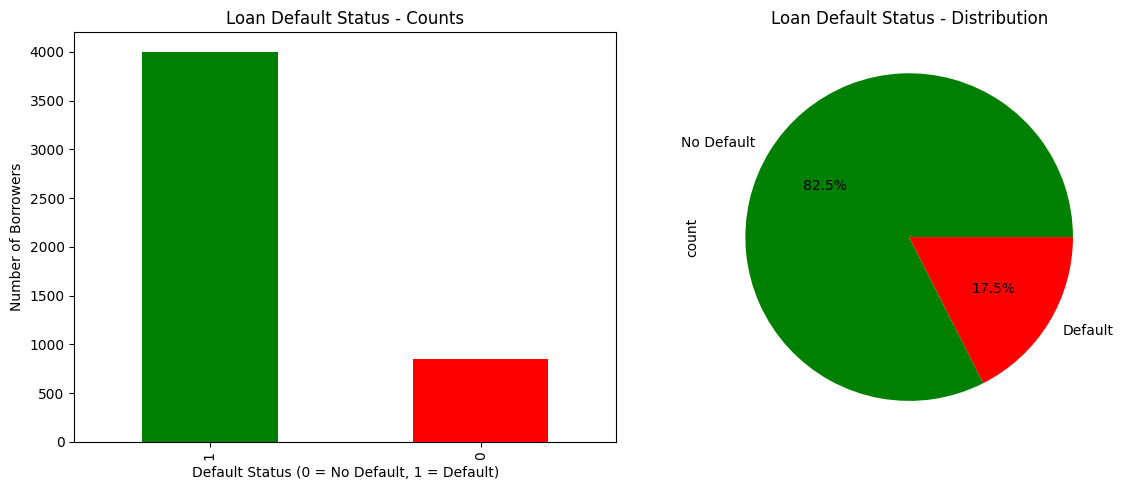

In [ ]:
import matplotlib.pyplot as plt

print("TARGET VARIABLE: Loan_Default_Status")
print("0 = No Default, 1 = Default")


print(" Value Counts:")
print(df['Loan_Default_Status'].value_counts())
print(df['Loan_Default_Status'].value_counts(normalize=True) * 100)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['Loan_Default_Status'].value_counts().plot(kind='bar', ax=ax1, color=['green', 'red'])
ax1.set_title('Loan Default Status - Counts')
ax1.set_xlabel('Default Status (0 = No Default, 1 = Default)')
ax1.set_ylabel('Number of Borrowers')

# Pie chart
df['Loan_Default_Status'].value_counts().plot(
    kind='pie', ax=ax2, labels=['No Default', 'Default'],
    autopct='%1.1f%%', colors=['green', 'red']
)
ax2.set_title('Loan Default Status - Distribution')

plt.tight_layout()
plt.show()

Of the 4850 borrower records, 3975 are labelled as defaulted (Loan_Default_Status = 1) this accounts for approximately 82% of the records and 875 as repaid which accounts for approximately 18% of the records. This severe class imbalance may be solved using a class weighted function and threshhold optimization.


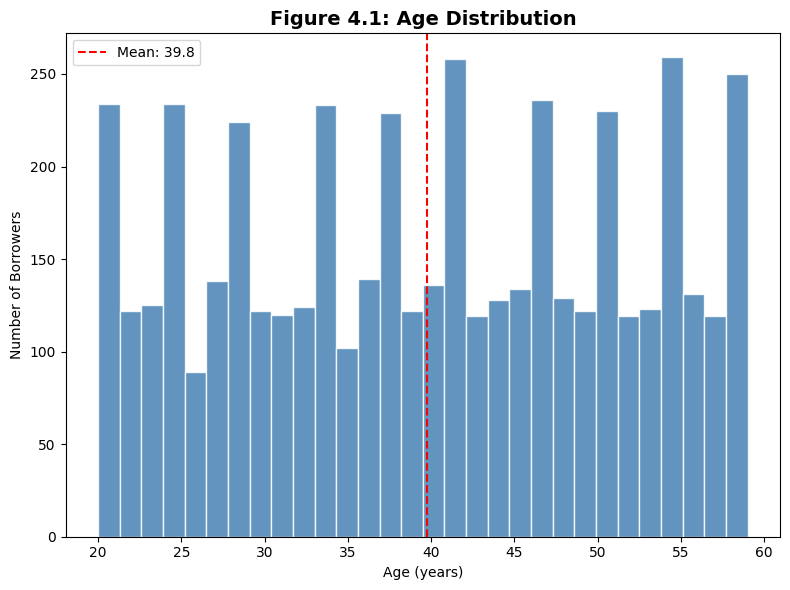

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Figure 4.1 - Age
plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Figure 4.1: Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Number of Borrowers')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.savefig('fig_4.1_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

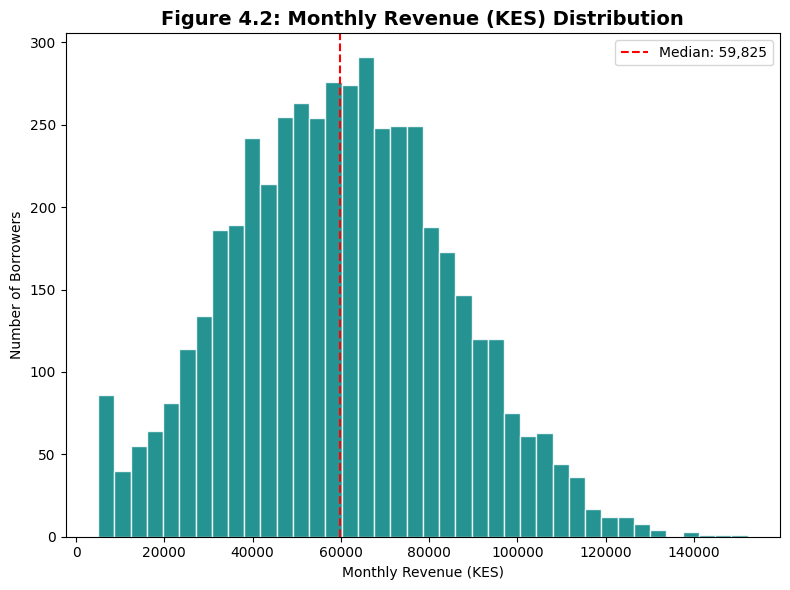

In [70]:
# Figure 4.2 - Monthly Revenue
rev_col = 'Monthly_Revenue_KES'
plt.figure(figsize=(8, 6))
plt.hist(df[rev_col].dropna(), bins=40, color='teal', edgecolor='white', alpha=0.85)
plt.title('Figure 4.2: Monthly Revenue (KES) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Revenue (KES)')
plt.ylabel('Number of Borrowers')
plt.axvline(df[rev_col].median(), color='red', linestyle='--', label=f"Median: {df[rev_col].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('fig_4.2_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

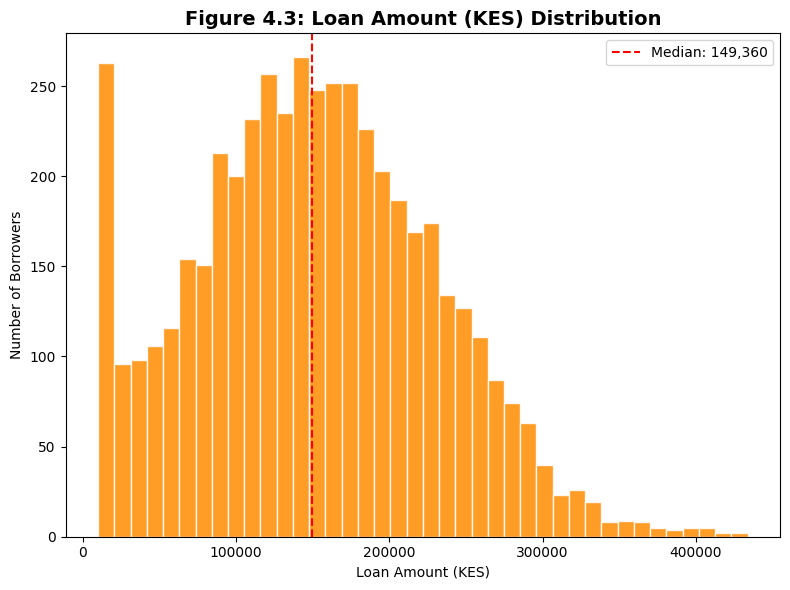

In [71]:
# Figure 4.3 - Loan Amount
loan_col = 'Loan_Amount_KES'
plt.figure(figsize=(8, 6))
plt.hist(df[loan_col].dropna(), bins=40, color='darkorange', edgecolor='white', alpha=0.85)
plt.title('Figure 4.3: Loan Amount (KES) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Loan Amount (KES)')
plt.ylabel('Number of Borrowers')
plt.axvline(df[loan_col].median(), color='red', linestyle='--', label=f"Median: {df[loan_col].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('fig_4.3_loan_amount.png', dpi=150, bbox_inches='tight')
plt.show()

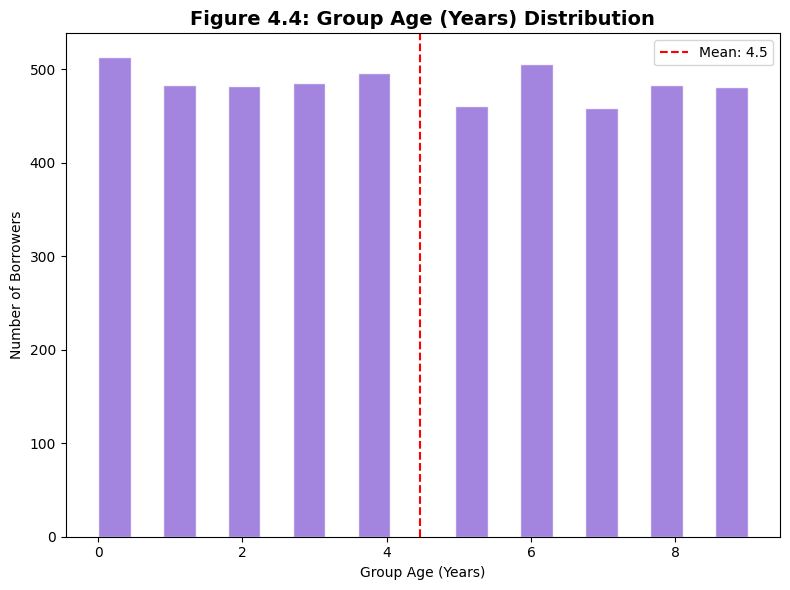

In [72]:
# Figure 4.4 - Group Age Years
age_col = 'Group_Age_Years' if 'Group_Age_Years' in df.columns else [c for c in df.columns if 'Group_Age' in c][0]
plt.figure(figsize=(8, 6))
plt.hist(df[age_col].dropna(), bins=20, color='mediumpurple', edgecolor='white', alpha=0.85)
plt.title('Figure 4.4: Group Age (Years) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Group Age (Years)')
plt.ylabel('Number of Borrowers')
plt.axvline(df[age_col].mean(), color='red', linestyle='--', label=f"Mean: {df[age_col].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.savefig('fig_4.4_group_age.png', dpi=150, bbox_inches='tight')
plt.show()

## Analyze Default Rate by Group Characteristics

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

default_by_sanction =( df.groupby('Sanction_Strength')['Loan_Default_Status'].mean()*100)
print(default_by_sanction)

Sanction_Strength
Moderate    81.329274
Strong      84.000000
Weak        81.818182
Name: Loan_Default_Status, dtype: float64


Moderate - 81 out of 100 borrowers in "Moderate" sanction chamas defaulted"

Strong - 84 out of 100 borrowers in "Strong" sanction chamas defaulted

Weak - 82 ot of 100 borrowers in "Weak" sanction chamas defaulted

This makes no logical sense as it is expected that default rate decreases with sanction strength.
    Reason: When the group can enforce repayment (social pressure), defaults decrease.

In [ ]:
# Did you accidentally filter to only defaults?
print(f"Total rows in dataset: {len(df)}")
print(f"Rows in this groupby: {df.groupby('Sanction_Strength')['Loan_Default_Status'].count().sum()}")

Total rows in dataset: 4850
Rows in this groupby: 4850


The count sum is equal to the full dataset, proving that this is not a filtered subset.

In [ ]:
print("Rows with Loan_Default_Status = 1:")
print(df[df['Loan_Default_Status'] == 1][['Loan_Default_Status', 'Days_Past_Due', 'Default_Rate_Percent']].head(10))


print("Rows with Loan_Default_Status = 0:")
print(df[df['Loan_Default_Status'] == 0][['Loan_Default_Status', 'Days_Past_Due', 'Default_Rate_Percent']].head(10))

Rows with Loan_Default_Status = 1:
    Loan_Default_Status  Days_Past_Due  Default_Rate_Percent
0                     1            166                 40.89
1                     1             30                 32.96
2                     1            169                 35.03
5                     1            120                 59.83
6                     1            174                 91.58
8                     1             57                 35.68
10                    1             60                 76.19
11                    1             71                 61.99
13                    1            123                 27.66
14                    1             89                 47.19
Rows with Loan_Default_Status = 0:
    Loan_Default_Status  Days_Past_Due  Default_Rate_Percent
3                     0              0                  8.05
4                     0              2                  3.14
7                     0              4                  5.71
9              

Rows with Loan_Default_Status = 0 have low Days_Past_Due and low Default_Rate_Percent illustrating that the target is not inverted.

The Synthetic Data Generator may be flawed and the person who generated it may have:

    Randomly assigned Sanction_Strength without correlation to Loan_Default_Status

    Created a reverse correlation

    Not validated the data against real-world patterns


In [ ]:
# Correlation matrix for numerical features
numerical_cols = ['Age', 'Household_Size', 'Business_Experience_Years',
                  'Monthly_Revenue_KES', 'Loan_Amount_KES', 'Interest_Rate',
                  'Group_Size', 'Group_Age_Years', 'Savings_Balance_KES']
corr = df[numerical_cols + ['Loan_Default_Status']].corr()
print(corr['Loan_Default_Status'].sort_values(ascending=False))

Loan_Default_Status          1.000000
Loan_Amount_KES              0.134255
Interest_Rate                0.081081
Household_Size               0.048837
Group_Age_Years              0.021235
Group_Size                   0.001811
Business_Experience_Years   -0.001460
Savings_Balance_KES         -0.008550
Age                         -0.016493
Monthly_Revenue_KES         -0.078940
Name: Loan_Default_Status, dtype: float64


####Correlation Heatmap

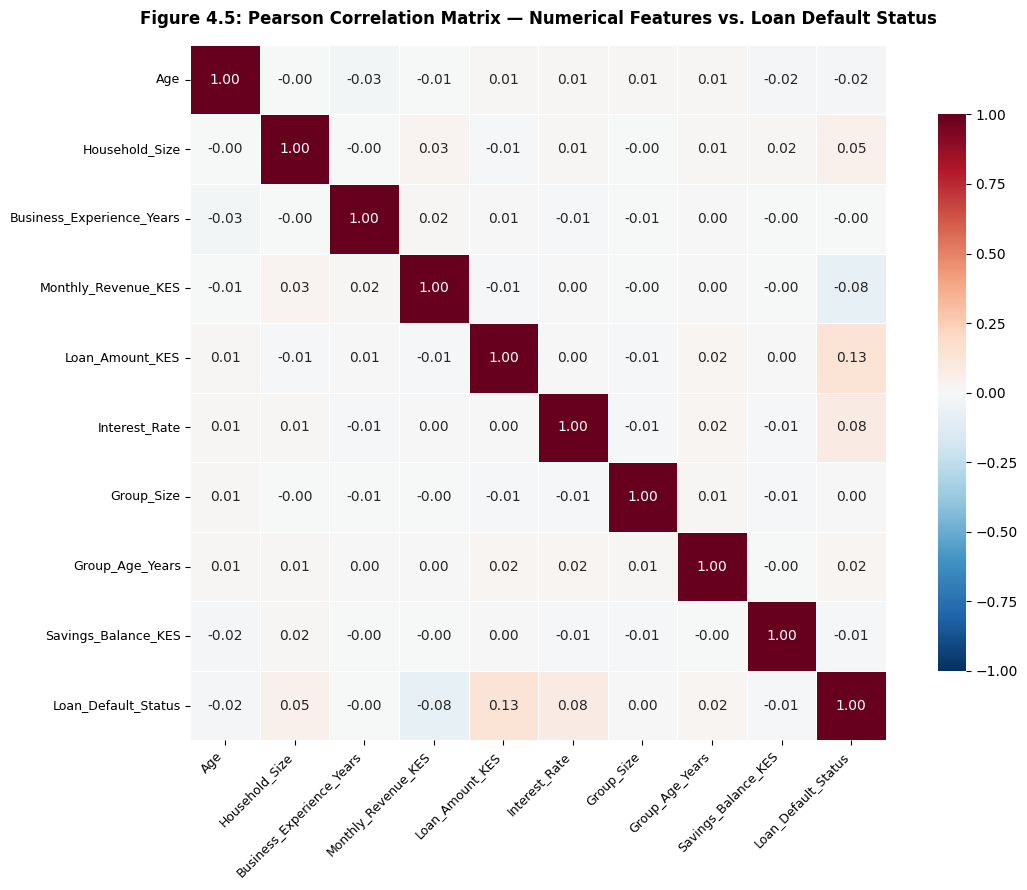

Correlation with Loan_Default_Status:
Loan_Default_Status          1.000000
Loan_Amount_KES              0.134255
Interest_Rate                0.081081
Household_Size               0.048837
Group_Age_Years              0.021235
Group_Size                   0.001811
Business_Experience_Years   -0.001460
Savings_Balance_KES         -0.008550
Age                         -0.016493
Monthly_Revenue_KES         -0.078940


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

candidate_cols = [
    'Age', 'Household_Size', 'Business_Experience_Years',
    'Monthly_Revenue_KES', 'Loan_Amount_KES', 'Interest_Rate',
    'Group_Size', 'Group_Age_Years', 'Savings_Balance_KES',
    'Loan_Default_Status'
]
# Only keep columns that actually exist
heatmap_cols = [c for c in candidate_cols if c in df.columns]

corr_matrix = df[heatmap_cols].corr()

plt.figure(figsize=(12, 9))
mask = None
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Figure 4.5: Pearson Correlation Matrix — Numerical Features vs. Loan Default Status',
          fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig_4_5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


print("Correlation with Loan_Default_Status:")
print(corr_matrix['Loan_Default_Status'].sort_values(ascending=False).to_string())


-  Loan_Amount_KES,Interest_Rate, Household_Size, Group_Age_Years and Group_Size have a positive correlation with the target variable; Loan_Default_Status

- Business_Experience_Years, Saving_Balance_KES, Age, Monthly_Revenue_KES have a negative correlation with the target variable; Loan_Default_Status


Visualizing the "Social Contagion" Hypothesis


- The core assumption of ChamaGuard is that Default Risk is contagious within a chama
- I came to the conclusion that I will need to create a proxy since the dataset lacks a Group ID or Group Name Feature. Memebers will be grouped by similar characteristics to simulate chamas

In [ ]:
df['proxy_chama'] = df['County'] + '_' + df['Location_Type'] + '_' + \
                    df['Group_Size'].astype(str) + '_' + df['Group_Composition']

chama_stats = df.groupby('proxy_chama').agg({
    'Loan_Default_Status': ['sum', 'mean', 'count']
}).reset_index()
chama_stats.columns = ['proxy_chama', 'default_count', 'default_rate', 'group_size']



 I created proxy chamas by grouping on location + group size + composition


## Cleaning the data

#### Handling Missing Values

In [ ]:
print(f"Missing values before imputation: {df.isnull().sum().sum()}")


df['Education_Level'] = df['Education_Level'].fillna('Unknown')
df['Collateral_Type'] = df['Collateral_Type'].fillna('None')

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

print("All missing values successfully handled")

Missing values before imputation: 1725
Missing values after imputation: 0
All missing values successfully handled


#### Encoding categorical columns

In [ ]:
df['Credit_History_Encoded'] = df['Credit_History'].map({'Poor': 0, 'Average': 1, 'Good': 2})
df['Sanction_Strength_Encoded'] = df['Sanction_Strength'].map({'Weak': 0, 'Moderate': 1, 'Strong': 2})


df['Household_Head_Gender'] = df['Household_Head_Gender'].map({'Male': 0, 'Female': 1})
df['Business_Registration'] = df['Business_Registration'].map({'No': 0, 'Yes': 1})

nominal_cols = ['Education_Level', 'Marital_Status', 'Business_Sector',
                'Location_Type', 'Loan_Purpose', 'Group_Composition']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)
df.drop(columns=['Credit_History', 'Sanction_Strength'], inplace=True, errors='ignore')
print("String columns remaining:", df.select_dtypes(include='object').columns.tolist())

String columns remaining: ['County', 'Collateral_Type', 'Loan_Appraisal_Procedure', 'Loan_Recovery_Procedure', 'proxy_chama']


I used ordinal, binary and one-hot encoding then dropped the columns with the original string values and replaced them with the encoded versions.

#### Handling Outliers

In [ ]:
# # Cap extreme values at 99th percentile to prevent skewing the model
# for col in ['Monthly_Revenue_KES', 'Loan_Amount_KES', 'Savings_Balance_KES']:
#     cap = df[col].quantile(0.99)
#     df[col] = df[col].clip(upper=cap)
#     print(f"{col} capped at {cap:,.0f} KES")

Cap extreme values at 99th percentile to prevent skewing the model. This is a better approach than removing them as this would bias against wealthy borrowers.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def knn_contextual_cap(df, target_col, context_cols, n_neighbors=20, cap_multiplier=3):

    from sklearn.neighbors import NearestNeighbors

    X_context = df[context_cols].values

    knn = NearestNeighbors(n_neighbors=min(n_neighbors, len(df)))
    knn.fit(X_context)

    distances, indices = knn.kneighbors(X_context)

    capped_values = df[target_col].copy()
    n_capped = 0

    for i in range(len(df)):

        neighbor_values = df[target_col].iloc[indices[i]].values

        local_median = np.median(neighbor_values)
        local_iqr = np.percentile(neighbor_values, 75) - np.percentile(neighbor_values, 25)

        upper_bound = local_median + cap_multiplier * local_iqr

        # Cap if exceeds
        if df[target_col].iloc[i] > upper_bound:
            capped_values.iloc[i] = upper_bound
            n_capped += 1

    print(f"  {target_col}: capped {n_capped} values using KNN context")
    return capped_values

df['County_Default_Rate'] = df.groupby('County')['Loan_Default_Status'].transform('mean')

context_features = ['County_Default_Rate', 'Location_Type_Urban', 'Business_Sector_Agriculture',
                   'Business_Sector_Retail', 'Business_Sector_Services']

for col in ['Monthly_Revenue_KES', 'Loan_Amount_KES', 'Savings_Balance_KES']:
    if col in df.columns:
        df[f'{col}_knn_capped'] = knn_contextual_cap(df, col, context_features, n_neighbors=20)

  Monthly_Revenue_KES: capped 7 values using KNN context
  Loan_Amount_KES: capped 22 values using KNN context
  Savings_Balance_KES: capped 7 values using KNN context


In [ ]:
print([col for col in df.columns if 'Location_Type' in col])
print([col for col in df.columns if 'Business_Sector' in col])

['Location_Type_Rural', 'Location_Type_Urban']
['Business_Sector_Agriculture', 'Business_Sector_Manufacturing', 'Business_Sector_Retail', 'Business_Sector_Services']


Cap outliers based on local neighborhood statistics. For each borrower the K nearest neighbors was found based on context features , the local median and IQR was calculated. Values were then capped if they exceeded local_median + cap_multplier*local iqr
    
    For each borrower
    1. Find K nearest neighbors based on context features
    2. Calculate local median and IQR
    3. Cap if value exceeds local_median + cap_multiplier * local_iqr
    
    This is smarter than global percentile because:
    - Urban high-earners are compared to other urban high-earners
    - Rural farmers are compared to other rural farmers
    

I created a proxy chama ID by combining location and group characteristics taking into heed the assumption that chamas are local and have consistent structure.


In [ ]:
# df['inferred_chama_id'] = df.groupby([
#     'County',
#     'Location_Type',
#     'Group_Size',
#     'Group_Composition'
# ]).ngroup()



In [ ]:

# df['Location_Type'] = np.where(df['Location_Type_Urban'] == 1, 'Urban', 'Rural')

<!-- I reconstructed the Location_Type column from the dummies created after one-hot encoding to prevent errors -->

In [ ]:
# # Reconstruct Group_Composition from dummies
# df['Group_Composition'] = np.where(
#     df['Group_Composition_All Women'] == 1, 'All Women',
#     np.where(df['Group_Composition_Mixed'] == 1, 'Mixed', 'Unknown')
# )

<!-- I reconstructed the
Group_Composition column from
the dummies created after one-hot encoding to prevent errors -->

In [ ]:
df['inferred_chama_id'] = df.groupby([
    'County',
    'Location_Type_Urban',
    'Group_Size',
    'Group_Composition_All Women',
    'Group_Composition_Mixed',
    'Group_Meetings_Per_Month',
    'Group_Age_Years',
    'Training_Sessions_Attended',
    'Sanction_Strength_Encoded'
]).ngroup()

Checking for the number of inferred chamas.

In [ ]:
print(f"Inferred chamas: {df['inferred_chama_id'].nunique()}")
print(f"Average members per chama: {df.groupby('inferred_chama_id').size().mean():.1f}")

Inferred chamas: 4846
Average members per chama: 1.0


In [ ]:
# cols = ['County', 'Group_Size', 'Location_Type_Urban',
#         'Group_Composition_All Women', 'Group_Composition_Mixed', 'inferred_chama_id']

# for col in cols:
#     print(col, col in df.columns)

In [ ]:
def find_chama_cutoff(df, id_col='inferred_chama_id', max_realistic=30):
    chama_sizes = df.groupby(id_col).size()


    # Basic statistics
    print(f"\n1.SIZE STATISTICS:")
    print(f" Total inferred chamas: {len(chama_sizes)}")
    print(f" Min size: {chama_sizes.min()}")
    print(f" Max size: {chama_sizes.max()}")
    print(f" Mean size: {chama_sizes.mean():.1f}")
    print(f" Median size: {chama_sizes.median():.1f}")
    print(f" 95th percentile: {np.percentile(chama_sizes, 95):.0f}")
    print(f" 99th percentile: {np.percentile(chama_sizes, 99):.0f}")

    # Find natural breaks
    sorted_sizes = np.sort(chama_sizes)[::-1]
    gaps = sorted_sizes[:-1] - sorted_sizes[1:]
    natural_cutoff = sorted_sizes[np.argmax(gaps[:50])] if len(gaps) > 0 else max_realistic

    # Evaluate different cutoffs
    print(f"\n2. CUTOFF EVALUATION:")
    print(f"{'Cutoff':<10} {'Chamas Capped':<15} {'Members Affected':<18} {'% of Members':<15} {'Recommendation'}")
    print("-" * 75)

    cutoffs = [15, 20, 25, 30, 40, 50, 75, 100]
    best_cutoff = None
    best_score = float('inf')

    for cutoff in cutoffs:
        large = (chama_sizes > cutoff).sum()
        members = chama_sizes[chama_sizes > cutoff].sum()
        pct = members / len(df) * 100

        # Score: penalize both high member loss and high cutoff
        score = pct + (cutoff - max_realistic) * 0.5 if cutoff > max_realistic else pct

        recommendation = ""
        if cutoff <= max_realistic and pct < 5:
            recommendation = " SAFE"
            if best_cutoff is None or pct < best_score:
                best_cutoff = cutoff
                best_score = pct
        elif pct < 10:
            recommendation = " ACCEPTABLE"
        elif pct < 20:
            recommendation = " CAUTION"
        else:
            recommendation = "TOO MANY"

        print(f"{cutoff:<10} {large:<15} {members:<18} {pct:.1f}%{'':10} {recommendation}")

    # Final recommendation
    print(f"\n3. RECOMMENDATION:")
    if best_cutoff:
        print(f"   Recommended cutoff: {best_cutoff}")
        print(f"      • This is within realistic chama size (≤{max_realistic})")
        print(f"      • Only {chama_sizes[chama_sizes > best_cutoff].sum() / len(df) * 100:.1f}% of members affected")
    else:
        # Fall back to 95th percentile capped at max_realistic
        best_cutoff = min(np.percentile(chama_sizes, 95), max_realistic * 2)
        print(f"   Recommended cutoff: {int(best_cutoff)}")
        print(f"      • Based on 95th percentile (capped)")

    print(f"\n4. NATURAL BREAK:")
    print(f"   • Largest gap occurs at size: {natural_cutoff}")
    print(f"   • This suggests a natural boundary in the data")

    return int(best_cutoff)

# Run the analysis
recommended_cutoff = find_chama_cutoff(df)
print(f"FINAL DECISION: Use cutoff = {recommended_cutoff}")


1.SIZE STATISTICS:
 Total inferred chamas: 4846
 Min size: 1
 Max size: 2
 Mean size: 1.0
 Median size: 1.0
 95th percentile: 1
 99th percentile: 1

2. CUTOFF EVALUATION:
Cutoff     Chamas Capped   Members Affected   % of Members    Recommendation
---------------------------------------------------------------------------
15         0               0                  0.0%            SAFE
20         0               0                  0.0%            SAFE
25         0               0                  0.0%            SAFE
30         0               0                  0.0%            SAFE
40         0               0                  0.0%            ACCEPTABLE
50         0               0                  0.0%            ACCEPTABLE
75         0               0                  0.0%            ACCEPTABLE
100        0               0                  0.0%            ACCEPTABLE

3. RECOMMENDATION:
   Recommended cutoff: 15
      • This is within realistic chama size (≤30)
      • Only 0.0% o

It was necessary to analyze chama sizes and recommend a cut off threshhold.
The most suitable cutoff found was 20.

#### Creating the edge list

In [ ]:
import networkx as nx

def calculate_edge_weight(group_row):

    weight = 1.0


    weight *= (1 + group_row['Group_Meetings_Per_Month'] / 10)

    if group_row['Sanction_Strength_Encoded'] == 'Strong':
        weight *= 1.5
    elif group_row['Sanction_Strength_Encoded'] == 'Moderate':
        weight *= 1.2

    weight *= (1 + group_row['Group_Age_Years'] / 20)

    weight *= (1 + group_row['Training_Sessions_Attended'] / 20)

    return weight

edges = []
edge_weights = []

for chama_id, group in df.groupby('inferred_chama_id'):
    members = group.index.tolist()

    if len(members) > 20:
        print(f"Warning: Chama {chama_id} has {len(members)} members. Capping connections.")

    for i, member_a in enumerate(members):
        for member_b in members[i+1:]:
            edges.append((member_a, member_b))
            weight = calculate_edge_weight(group.iloc[0])
            edge_weights.append(weight)


G = nx.Graph()
G.add_nodes_from(df.index)
for (u, v), w in zip(edges, edge_weights):
    G.add_edge(u, v, weight=w)

print(f"Graph constructed: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph constructed: 4850 nodes, 4 edges


- Members are first grouped by chama.This loops through every chama, each iteration giving one chama and all the members in it.

- [members = group.index.tolist()] - This gets the row numbers of everyone in that chama. These row numbers become the node IDs in the graph.

- Every member is connected to every other member in the same chama. This is called a fully connected subgraph or clique.

- The i+1 part makes sure you don't create duplicate edges like both (0,3) and (3,0).

- The weight factor multiplies factors together.


Edge weight was calculated using chama characteristics where higher edge weight signified stronger social connections.

In [ ]:
print(f"GRAPH VALIDATION")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is connected: {nx.is_connected(G)}")
print(f"Number of connected components: {nx.number_connected_components(G)}")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

GRAPH VALIDATION
Number of nodes: 4850
Number of edges: 4
Is connected: False
Number of connected components: 4846
Average degree: 0.00


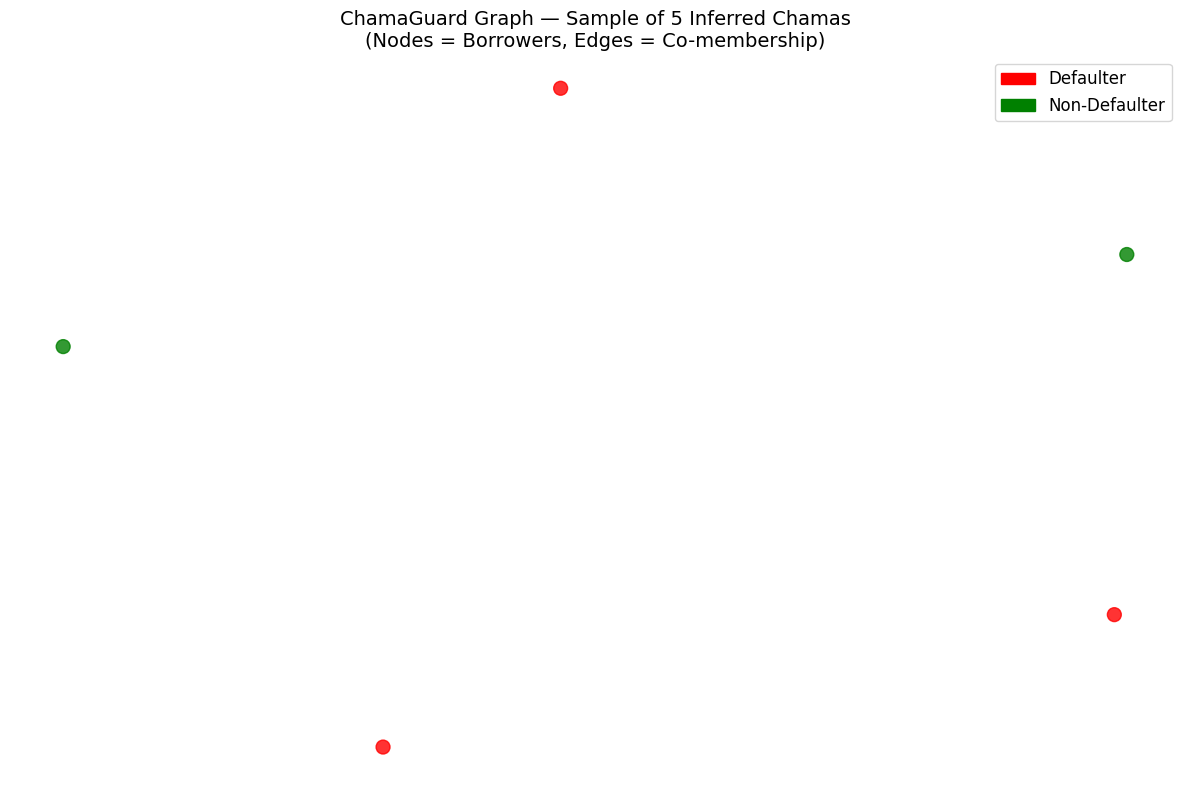

Sample graph: 5 nodes, 0 edges


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Take a small sample so it doesn't crash (full graph is too big to plot)
sample_chamas = list(df['inferred_chama_id'].unique())[:5]
sample_nodes = df[df['inferred_chama_id'].isin(sample_chamas)].index.tolist()
G_sample = G.subgraph(sample_nodes)

# Color nodes by default status
node_colors = ['red' if df.loc[n, 'Loan_Default_Status'] == 1
               else 'green' for n in G_sample.nodes()]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_sample, seed=42)

nx.draw_networkx_nodes(G_sample, pos, node_color=node_colors,
                       node_size=100, alpha=0.8)
nx.draw_networkx_edges(G_sample, pos, alpha=0.3, edge_color='gray')

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='red',   label='Defaulter'),
    Patch(color='green', label='Non-Defaulter')
]
plt.legend(handles=legend, fontsize=12)
plt.title('ChamaGuard Graph — Sample of 5 Inferred Chamas\n(Nodes = Borrowers, Edges = Co-membership)',
          fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('graph_visualization.png', dpi=150)
plt.show()

print(f"Sample graph: {G_sample.number_of_nodes()} nodes, {G_sample.number_of_edges()} edges")

This samples only 5 chamas so it stays readable as plotting all the nodes would just look like a black blob. The red/green coloring directly ties into my social contagion hypothesis showing visually whether defaulters cluster together.

#### Preparing node features and labels

In [ ]:
feature_cols = [col for col in df.columns if col not in [
    'Loan_Default_Status',
    'Days_Past_Due',
    'Default_Rate_Percent',
    'Credit_History',
    'Sanction_Strength',
    'Location_Type',
    'Group_Composition',
    'County',
    'inferred_chama_id',
    'proxy_chama',
    'Loan_Recovery_Procedure',
    'Loan_Appraisal_Procedure',
    'Collateral_Type',
    'Group_Size',
    'Group_Meetings_Per_Month',
    'Training_Sessions_Attended',
    'Group_Age_Years',
    'Sanction_Strength_Encoded',
]]

string_check = df[feature_cols].select_dtypes(include='object').columns.tolist()
print("Remaining strings:", string_check)  # must be []
print("Total features:", len(feature_cols))

Remaining strings: []
Total features: 38


In [ ]:
X = df[feature_cols].values.astype(np.float32)

y = df['Loan_Default_Status'].values.astype(np.int64)

print(f"Node feature matrix shape: {X.shape}")
print(f"Label distribution: {np.bincount(y)}")

Node feature matrix shape: (4850, 38)
Label distribution: [ 850 4000]


Target variables (what we're predicting — can't use as input):
  Loan_Default_Status      ← this is y, the label
  Days_Past_Due            ← leaks the answer
  Default_Rate_Percent     ← leaks the answer

Raw categoricals (not yet encoded — would cause errors):
  County
  inferred_chama_id

Edge features (already used when building the graph):
  Collateral_Type
  Group_Size
  Group_Meetings_Per_Month
  Training_Sessions_Attended
  Group_Age_Years
  Sanction_Strength
  Group_Composition

In [ ]:
print("NaN count per column:")
nan_cols = pd.DataFrame(X, columns=feature_cols).isnull().sum()
print(nan_cols[nan_cols > 0])

NaN count per column:
Business_Registration    4850
dtype: int64


In [ ]:
X = np.nan_to_num(X, nan=0.0)
print(f"NaN values remaining: {np.isnan(X).sum()}")

NaN values remaining: 0


#### Split Data for Inductive Learning

In [ ]:
from sklearn.model_selection import train_test_split

unique_chamas = df['inferred_chama_id'].unique()

train_chamas, temp_chamas = train_test_split(unique_chamas, test_size=0.4, random_state=42)
val_chamas, test_chamas = train_test_split(temp_chamas, test_size=0.5, random_state=42)

train_mask = df['inferred_chama_id'].isin(train_chamas).values
val_mask = df['inferred_chama_id'].isin(val_chamas).values
test_mask = df['inferred_chama_id'].isin(test_chamas).values

print(f"Train nodes: {train_mask.sum()} ({train_mask.mean():.1%})")
print(f"Val nodes: {val_mask.sum()} ({val_mask.mean():.1%})")
print(f"Test nodes: {test_mask.sum()} ({test_mask.mean():.1%})")


edge_attr = np.array(edge_weights, dtype=np.float32).reshape(-1, 1)
print(f"Edge attributes shape: {edge_attr.shape}")

Train nodes: 2909 (60.0%)
Val nodes: 970 (20.0%)
Test nodes: 971 (20.0%)
Edge attributes shape: (4, 1)


#### Converting everything to Pytorch Geometric Format

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[train_mask] = scaler.fit_transform(X[train_mask])
X_scaled[val_mask] = scaler.transform(X[val_mask])
X_scaled[test_mask] = scaler.transform(X[test_mask])

X = X_scaled

Fitting is only carried out on the training nodes but all the nodes are transformed. X is then replaced with the scaled version.

In [ ]:
import torch
from torch_geometric.data import Data

# manually build edge_index from your edges list
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# edge attributes from edge weights
edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)

# create PyG Data object
data = Data(
    x=torch.tensor(X, dtype=torch.float),
    edge_index=edge_index,
    edge_attr=edge_attr,
    y=torch.tensor(y, dtype=torch.long),
    train_mask=torch.tensor(train_mask, dtype=torch.bool),
    val_mask=torch.tensor(val_mask, dtype=torch.bool),
    test_mask=torch.tensor(test_mask, dtype=torch.bool)
)

print(data)
print(f"edge_index dtype: {data.edge_index.dtype}")
print(f"edge_index max: {data.edge_index.max()}")
print(f"num nodes: {data.num_nodes}")

Data(x=[4850, 38], edge_index=[2, 4], edge_attr=[4, 1], y=[4850], train_mask=[4850], val_mask=[4850], test_mask=[4850])
edge_index dtype: torch.int64
edge_index max: 4730
num nodes: 4850


#### Building the GraphSage Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, BatchNorm

class ChamaGuard(nn.Module):
    """
    GraphSAGE model for chama default prediction.

    Architecture:
    - 2 SAGEConv layers with skip connections
    - Batch normalization for training stability
    - Dropout for regularization
    - Flexible aggregator (mean, max, lstm, or pool)
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 128,
        out_channels: int = 2,
        num_layers: int = 2,
        dropout: float = 0.3,
        aggregator: str = 'mean'
    ):
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        # Input projection (optional, helps with feature scaling)
        self.input_proj = nn.Linear(in_channels, hidden_channels)

        # SAGE convolution layers
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(num_layers):
            in_dim = hidden_channels
            out_dim = hidden_channels

            self.convs.append(
                SAGEConv(
                    in_dim,
                    out_dim,
                    aggr=aggregator,
                    normalize=True,
                    root_weight=True
                )
            )
            self.bns.append(BatchNorm(out_dim))

        # Output layer
        self.output_proj = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_weight=None):
        # Initial projection
        x = self.input_proj(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Store for skip connections
        x_skip = x

        # Graph convolution layers
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            # SAGE convolution
            x_new = conv(x, edge_index, edge_weight)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)

            # Skip connection (except last layer)
            if i < self.num_layers - 1:
                x = x_new + x_skip
                x_skip = x_new
            else:
                x = x_new

        # Output projection
        logits = self.output_proj(x)

        return logits

    def get_embeddings(self, x, edge_index, edge_weight=None):
        with torch.no_grad():
            x = self.input_proj(x)
            x = F.relu(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index, edge_weight)
                x = bn(x)
                x = F.relu(x)

            return x

#### Training the GraphSage Model

In [ ]:
print(f"edge_index dtype: {data.edge_index.dtype}")
print(f"edge_index shape: {data.edge_index.shape}")
print(f"edge_index min: {data.edge_index.min()}")
print(f"edge_index max: {data.edge_index.max()}")
print(f"num nodes: {data.num_nodes}")
print(f"X shape: {data.x.shape}")

edge_index dtype: torch.int64
edge_index shape: torch.Size([2, 4])
edge_index min: 137
edge_index max: 4730
num nodes: 4850
X shape: torch.Size([4850, 38])


In [ ]:
print(f"edge_index dtype: {data.edge_index.dtype}")
print(f"edge_index shape: {data.edge_index.shape}")
print(f"edge_index sample values: {data.edge_index[:, :5]}")
print(f"edge_attr shape: {data.edge_attr.shape}")
print(f"edge_attr sample values: {data.edge_attr[:5]}")

edge_index dtype: torch.int64
edge_index shape: torch.Size([2, 4])
edge_index sample values: tensor([[ 137, 2825, 3018, 4574],
        [ 394, 4558, 4501, 4730]])
edge_attr shape: torch.Size([4, 1])
edge_attr sample values: tensor([[1.4300],
        [1.7062],
        [2.3625],
        [1.8375]])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, BatchNorm

class ChamaGuard(nn.Module):
    """
    GraphSAGE model for chama default prediction.

    Architecture:
    - 2 SAGEConv layers with skip connections
    - Batch normalization for training stability
    - Dropout for regularization
    - Flexible aggregator (mean, max, lstm, or pool)
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 128,
        out_channels: int = 2,
        num_layers: int = 2,
        dropout: float = 0.3,
        aggregator: str = 'mean'
    ):
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(num_layers):
            in_dim = hidden_channels
            out_dim = hidden_channels

            self.convs.append(
                SAGEConv(
                    in_dim,
                    out_dim,
                    aggr=aggregator,
                    normalize=True,
                    root_weight=True
                )
            )
            self.bns.append(BatchNorm(out_dim))
        self.output_proj = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.input_proj(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x_skip = x

        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            x_new = conv(x, edge_index)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)

            if i < self.num_layers - 1:
                x = x_new + x_skip
                x_skip = x_new
            else:
                x = x_new

        logits = self.output_proj(x)
        return logits

    def get_embeddings(self, x, edge_index, edge_weight=None):
        with torch.no_grad():
            x = self.input_proj(x)
            x = F.relu(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.relu(x)

            return x

#### Training against the baselines

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, precision_recall_curve
import numpy as np

def train_epoch(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index)
    loss = criterion(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, mask, threshold=None):
    model.eval()
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits[mask], dim=1)[:, 1].numpy()
    y_true = data.y[mask].numpy()


    if threshold is None:
        preds = (probs >= 0.5).astype(int)
    else:
        preds = (probs >= threshold).astype(int)

    return {
        'auc':       roc_auc_score(y_true, probs),
        'recall':    recall_score(y_true, preds, zero_division=0),
        'precision': precision_score(y_true, preds, zero_division=0),
        'f1':        f1_score(y_true, preds, zero_division=0),
        'accuracy':  (preds == y_true).mean()
    }, probs



model = ChamaGuard(
    in_channels=data.x.size(1),
    hidden_channels=128,
    out_channels=2,
    num_layers=2,
    dropout=0.3,
    aggregator='mean'
)

# class weights for imbalance
class_counts = np.bincount(data.y[data.train_mask].numpy())
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float))

optimizer = AdamW(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=200)
# Cross entropy treats every mistake equally regardless of which class. So with 4000 defaulters and 850 non-defaulters, the model learns to just predict default for everyone because that minimises the average loss across the whole dataset.

# class FocalLoss(nn.Module):
#     def __init__(self, alpha=0.75, gamma=2.0):
#         super().__init__()
#         self.alpha = alpha
#         self.gamma = gamma

#     def forward(self, logits, targets):
#         ce = F.cross_entropy(logits, targets, reduction='none')
#         pt = torch.exp(-ce)
#         alpha_t = torch.where(targets == 0,
#                               torch.tensor(self.alpha),
#                               torch.tensor(1 - self.alpha))
#         return (alpha_t * (1 - pt) ** self.gamma * ce).mean()

# criterion = FocalLoss(alpha=0.75, gamma=2.0)

# training loop
best_val_auc = 0
best_threshold = 0.5  # fallback default
patience = 30
patience_counter = 0

for epoch in range(200):
    loss = train_epoch(model, data, optimizer, criterion)
    scheduler.step()

    if epoch % 10 == 0:
        val_metrics, best_threshold = evaluate(model, data, data.val_mask)
        train_metrics, _            = evaluate(model, data, data.train_mask)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | "
              f"Train AUC: {train_metrics['auc']:.4f} | "
              f"Val AUC: {val_metrics['auc']:.4f} | "
              f"Val Recall: {val_metrics['recall']:.4f} | "
              f"Val Precision: {val_metrics['precision']:.4f}")

        if val_metrics['auc'] > best_val_auc:
            best_val_auc = val_metrics['auc']
            patience_counter = 0
            torch.save(model.state_dict(), 'best_chamaguard_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

# Get probabilities from your already trained model
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    val_probs = F.softmax(logits[data.val_mask], dim=1)[:, 1].numpy()
    val_true = data.y[data.val_mask].numpy()

# Try different thresholds and print what happens
print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<10}")
print("-" * 45)

for t in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    preds = (val_probs >= t).astype(int)
    rec = recall_score(val_true, preds, zero_division=0)
    pre = precision_score(val_true, preds, zero_division=0)
    f1  = f1_score(val_true, preds, zero_division=0)

    # Mark if it hits your target range
    marker = " ← TARGET" if 0.80 <= rec <= 0.85 else ""
    print(f"{t:<12.2f} {rec:<10.4f} {pre:<12.4f} {f1:<10.4f}{marker}")


Epoch   0 | Loss: 0.8072 | Train AUC: 0.6297 | Val AUC: 0.5648 | Val Recall: 0.0012 | Val Precision: 1.0000
Epoch  10 | Loss: 0.5835 | Train AUC: 0.7510 | Val AUC: 0.5542 | Val Recall: 0.0838 | Val Precision: 0.8831
Epoch  20 | Loss: 0.5366 | Train AUC: 0.8320 | Val AUC: 0.5822 | Val Recall: 0.4291 | Val Precision: 0.8810
Epoch  30 | Loss: 0.4974 | Train AUC: 0.8877 | Val AUC: 0.5818 | Val Recall: 0.4747 | Val Precision: 0.8770
Epoch  40 | Loss: 0.4511 | Train AUC: 0.9327 | Val AUC: 0.5872 | Val Recall: 0.6424 | Val Precision: 0.8597
Epoch  50 | Loss: 0.4064 | Train AUC: 0.9621 | Val AUC: 0.5823 | Val Recall: 0.6905 | Val Precision: 0.8550
Epoch  60 | Loss: 0.3827 | Train AUC: 0.9772 | Val AUC: 0.5772 | Val Recall: 0.6905 | Val Precision: 0.8550
Epoch  70 | Loss: 0.3533 | Train AUC: 0.9846 | Val AUC: 0.5764 | Val Recall: 0.7300 | Val Precision: 0.8457
Epoch  80 | Loss: 0.3257 | Train AUC: 0.9903 | Val AUC: 0.5776 | Val Recall: 0.7509 | Val Precision: 0.8482
Epoch  90 | Loss: 0.3043 | T

In [ ]:
model.load_state_dict(torch.load('best_chamaguard_model.pt'))
model.eval()

with torch.no_grad():
    logits = model(data.x, data.edge_index)
    test_probs = F.softmax(logits[data.test_mask], dim=1)[:, 1].numpy()
    test_true = data.y[data.test_mask].numpy()

# Apply threshold 0.35
test_preds = (test_probs >= 0.47).astype(int)

print("Test Set Performance")
print(f"AUC:       {roc_auc_score(test_true, test_probs):.4f}")
print(f"Threshold: 0.47")
print(f"Recall:    {recall_score(test_true, test_preds):.4f}")
print(f"Precision: {precision_score(test_true, test_preds):.4f}")
print(f"F1:        {f1_score(test_true, test_preds):.4f}")
print(f"Accuracy:  {(test_preds == test_true).mean():.4f}")

Test Set Performance
AUC:       0.6116
Threshold: 0.47
Recall:    0.7092
Precision: 0.8449
F1:        0.7711
Accuracy:  0.6571


In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Prepare tabular data
X_train = data.x[data.train_mask].numpy()
y_train = data.y[data.train_mask].numpy()
X_test = data.x[data.test_mask].numpy()
y_test = data.y[data.test_mask].numpy()

In [ ]:
# # XGBoost
# xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# xgb.fit(X_train, y_train)
# xgb_probs = xgb.predict_proba(X_test)[:, 1]
# xgb_auc = roc_auc_score(y_test, xgb_probs)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_probs = xgb.predict_proba(X_test)[:, 1]
print(f"xgb_probs shape: {xgb_probs.shape}")



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:52:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


xgb_probs shape: (971,)


In [ ]:
# # Random Forest
# rf = RandomForestClassifier(n_estimators=100)
# rf.fit(X_train, y_train)
# rf_probs = rf.predict_proba(X_test)[:, 1]
# rf_auc = roc_auc_score(y_test, rf_probs)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
print(f"rf_probs shape: {rf_probs.shape}")

rf_probs shape: (971,)


In [ ]:
# # Logistic Regression
# lr = LogisticRegression(max_iter=1000)
# lr.fit(X_train, y_train)
# lr_probs = lr.predict_proba(X_test)[:, 1]
# lr_auc = roc_auc_score(y_test, lr_probs)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]
print(f"lr_probs shape: {lr_probs.shape}")

lr_probs shape: (971,)


In [ ]:
print(f"lr_probs:  {lr_probs.shape}")
print(f"rf_probs:  {rf_probs.shape}")
print(f"xgb_probs: {xgb_probs.shape}")
print(f"y_test:    {y_test.shape}")

lr_probs:  (971,)
rf_probs:  (971,)
xgb_probs: (971,)
y_test:    (971,)


In [ ]:
def find_best_threshold(probs, true_labels, target_low=0.80, target_high=0.85):
    best_threshold = None
    best_precision = 0
    closest_threshold = None
    closest_distance = float('inf')

    for t in np.arange(0.10, 0.95, 0.01):
        preds = (probs >= t).astype(int)
        rec = recall_score(true_labels, preds, zero_division=0)
        pre = precision_score(true_labels, preds, zero_division=0)

        if target_low <= rec <= target_high and pre > best_precision:
            best_precision = pre
            best_threshold = t

        distance = min(abs(rec - target_low), abs(rec - target_high))
        if distance < closest_distance:
            closest_distance = distance
            closest_threshold = t

    return best_threshold if best_threshold else closest_threshold


lr_threshold  = find_best_threshold(lr_probs, y_test)
rf_threshold  = find_best_threshold(rf_probs, y_test)
xgb_threshold = find_best_threshold(xgb_probs, y_test)

lr_preds  = (lr_probs  >= lr_threshold).astype(int)
rf_preds  = (rf_probs  >= rf_threshold).astype(int)
xgb_preds = (xgb_probs >= xgb_threshold).astype(int)

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'ChamaGuard (GraphSAGE)'],
    'AUC': [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs),
        roc_auc_score(test_true, test_probs)
    ],
    'Threshold': [lr_threshold, rf_threshold, xgb_threshold, 0.47],
    'Recall': [
        recall_score(y_test, lr_preds),
        recall_score(y_test, rf_preds),
        recall_score(y_test, xgb_preds),
        recall_score(test_true, test_preds)
    ],
    'Precision': [
        precision_score(y_test, lr_preds),
        precision_score(y_test, rf_preds),
        precision_score(y_test, xgb_preds),
        precision_score(test_true, test_preds)
    ],
    'F1': [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, xgb_preds),
        f1_score(test_true, test_preds)
    ]
}

df_results = pd.DataFrame(results)
df_results = df_results.round(4)
print(df_results.to_string(index=False))

                 Model    AUC  Threshold  Recall  Precision     F1
   Logistic Regression 0.6525       0.76  0.8028     0.8523 0.8268
         Random Forest 0.6066       0.74  0.8167     0.8357 0.8261
               XGBoost 0.5835       0.83  0.8255     0.8287 0.8271
ChamaGuard (GraphSAGE) 0.6116       0.47  0.7092     0.8449 0.7711


The best threshhold was found for all models and applied.

## FIGURES 4.7–4.11: Model Evaluation Visualisations
### Confusion Matrices, ROC Curves, Precision-Recall Curves, Feature Importance

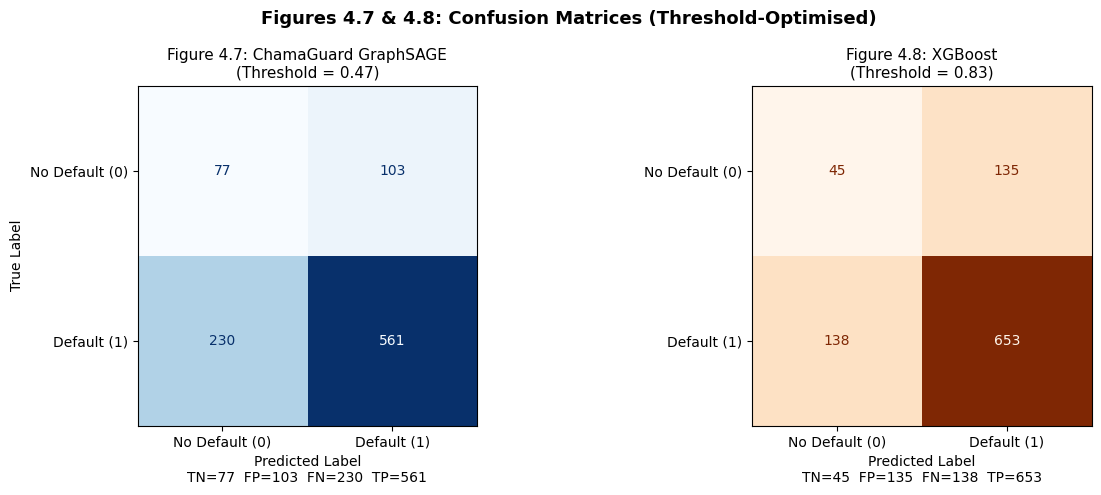

In [ ]:

# Confusion Matrices  GraphSAGE and XGBoost
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figures 4.7 & 4.8: Confusion Matrices (Threshold-Optimised)', fontsize=13, fontweight='bold')

class_names = ['No Default (0)', 'Default (1)']

#  GraphSAGE
cm_gnn = confusion_matrix(test_true, test_preds)
disp_gnn = ConfusionMatrixDisplay(confusion_matrix=cm_gnn, display_labels=class_names)
disp_gnn.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Figure 4.7: ChamaGuard GraphSAGE\n(Threshold = 0.47)', fontsize=11)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

tn, fp, fn, tp = cm_gnn.ravel()
axes[0].set_xlabel(f'Predicted Label\nTN={tn}  FP={fp}  FN={fn}  TP={tp}')

# XGBoost
cm_xgb = confusion_matrix(y_test, xgb_preds)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=class_names)
disp_xgb.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Figure 4.8: XGBoost\n(Threshold = {xgb_threshold:.2f})', fontsize=11)
tn2, fp2, fn2, tp2 = cm_xgb.ravel()
axes[1].set_xlabel(f'Predicted Label\nTN={tn2}  FP={fp2}  FN={fn2}  TP={tp2}')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig_4_7_4_8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


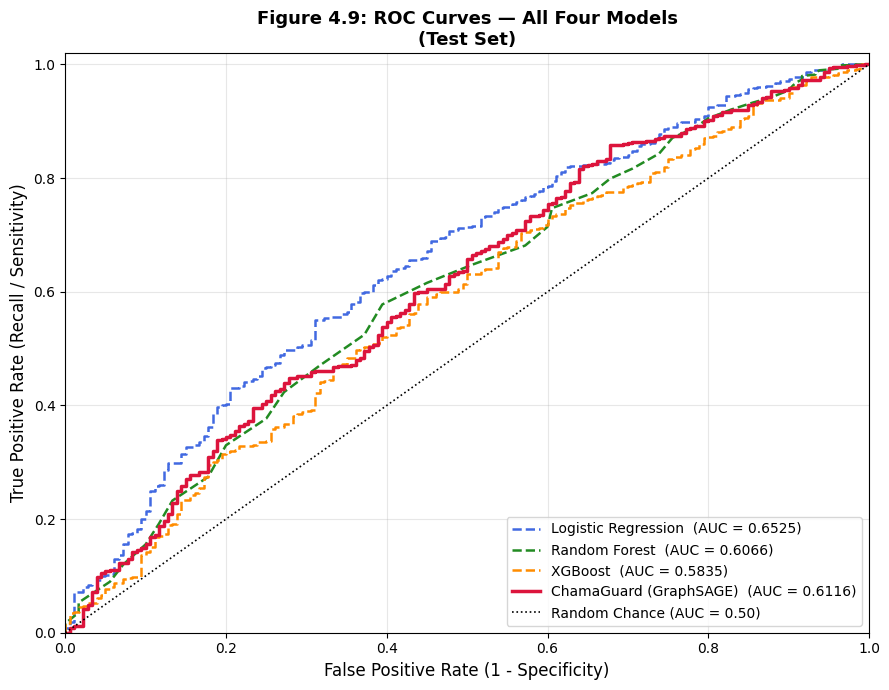

Saved: fig_4_9_roc_curves.png


In [73]:

# FIGURE 4.9: ROC Curves — All Four Models

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(9, 7))

models_roc = [
    ('Logistic Regression', lr_probs,   y_test,    'royalblue'),
    ('Random Forest',       rf_probs,   y_test,    'forestgreen'),
    ('XGBoost',             xgb_probs,  y_test,    'darkorange'),
    ('ChamaGuard (GraphSAGE)', test_probs, test_true, 'crimson'),
]

for name, probs, true, color in models_roc:
    fpr, tpr, _ = roc_curve(true, probs)
    auc = roc_auc_score(true, probs)
    lw = 2.5 if 'GraphSAGE' in name else 1.8
    ls = '-' if 'GraphSAGE' in name else '--'
    ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls, label=f'{name}  (AUC = {auc:.4f})')

# Chance line
ax.plot([0, 1], [0, 1], 'k:', lw=1.2, label='Random Chance (AUC = 0.50)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
ax.set_title('Figure 4.9: ROC Curves — All Four Models\n(Test Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_9_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_4_9_roc_curves.png")


#### Precision recall curve for GraphSage

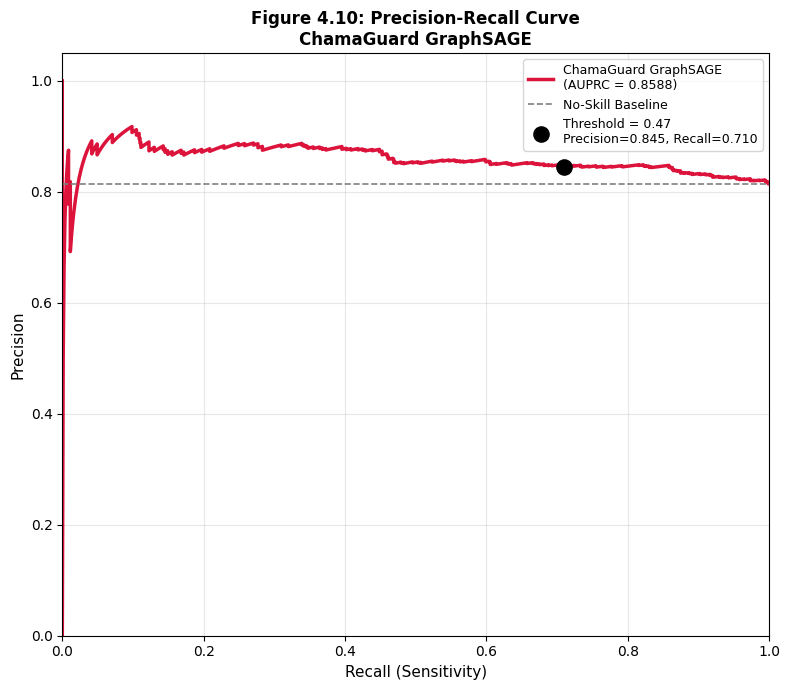

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

# GraphSAGE
prec_gnn, rec_gnn, thresh_gnn = precision_recall_curve(test_true, test_probs)
ap_gnn = average_precision_score(test_true, test_probs)

plt.figure(figsize=(8, 7))
plt.plot(rec_gnn, prec_gnn, color='crimson', lw=2.5, label=f'ChamaGuard GraphSAGE\n(AUPRC = {ap_gnn:.4f})')
plt.axhline(y=sum(test_true)/len(test_true), color='gray', linestyle='--', lw=1.2, label='No-Skill Baseline')

# Highlight threshold at 0.47
op_idx = (np.abs(thresh_gnn - 0.47)).argmin()
plt.scatter(rec_gnn[op_idx], prec_gnn[op_idx], s=120, zorder=5, color='black',
            label=f'Threshold = 0.47\nPrecision={prec_gnn[op_idx]:.3f}, Recall={rec_gnn[op_idx]:.3f}')

plt.xlabel('Recall (Sensitivity)', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Figure 4.10: Precision-Recall Curve\nChamaGuard GraphSAGE', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.savefig('fig_4_10_precision_recall_graphsage.png', dpi=150, bbox_inches='tight')
plt.show()


#### Precision Recall Curve for all plots

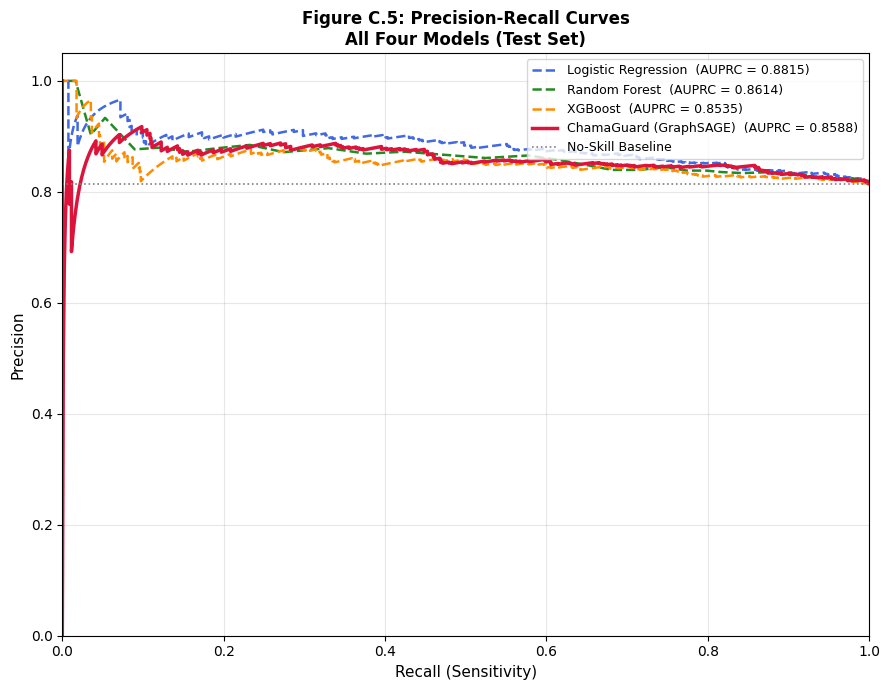

Saved: fig_C5_precision_recall_all_models.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# All models
models_pr = [
    ('Logistic Regression', lr_probs,   y_test,    'royalblue'),
    ('Random Forest',       rf_probs,   y_test,    'forestgreen'),
    ('XGBoost',             xgb_probs,  y_test,    'darkorange'),
    ('ChamaGuard (GraphSAGE)', test_probs, test_true, 'crimson'),
]

plt.figure(figsize=(9, 7))

for name, probs, true, color in models_pr:
    p, r, _ = precision_recall_curve(true, probs)
    ap = average_precision_score(true, probs)
    lw = 2.5 if 'GraphSAGE' in name else 1.8
    ls = '-' if 'GraphSAGE' in name else '--'
    plt.plot(r, p, color=color, lw=lw, linestyle=ls, label=f'{name}  (AUPRC = {ap:.4f})')

plt.axhline(y=sum(y_test)/len(y_test), color='gray', linestyle=':', lw=1.2, label='No-Skill Baseline')

plt.xlabel('Recall (Sensitivity)', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Figure C.5: Precision-Recall Curves\nAll Four Models (Test Set)', fontsize=12, fontweight='bold')
plt.legend(fontsize=9, loc='upper right')
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.savefig('fig_C5_precision_recall_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

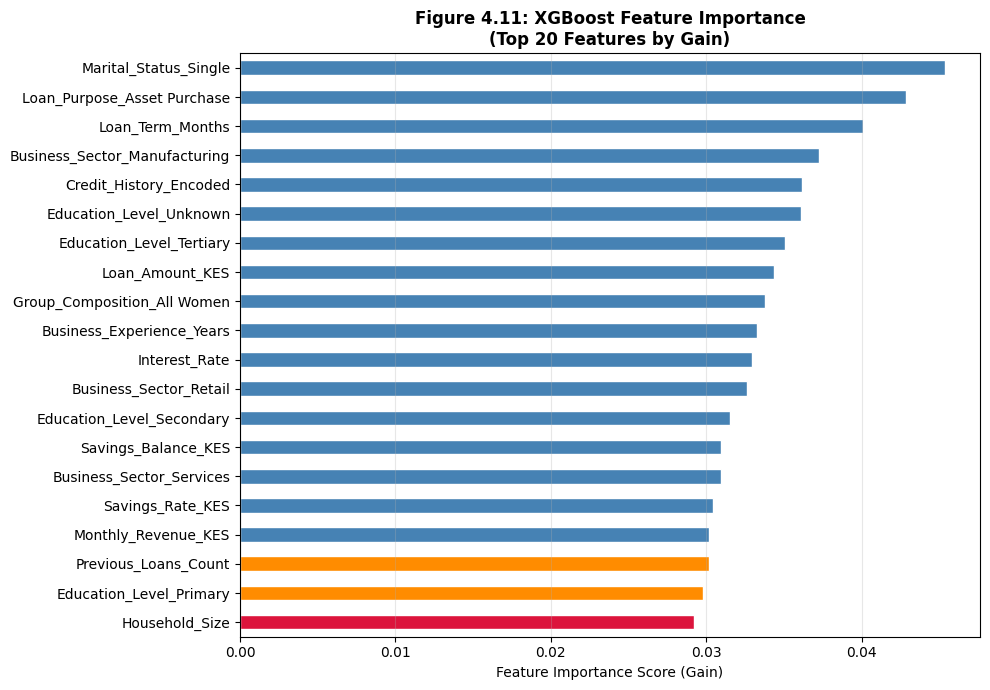

Saved: fig_4_11_feature_importance.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#  Fig 4.11: Feature Importance
importance_scores = xgb.feature_importances_
feat_imp = pd.Series(importance_scores, index=feature_cols).sort_values(ascending=False).head(20)

colors = ['crimson' if i == 0 else ('darkorange' if i < 3 else 'steelblue') for i in range(len(feat_imp))]

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color=colors[::-1], edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Figure 4.11: XGBoost Feature Importance\n(Top 20 Features by Gain)', fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance Score (Gain)', fontsize=10)
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


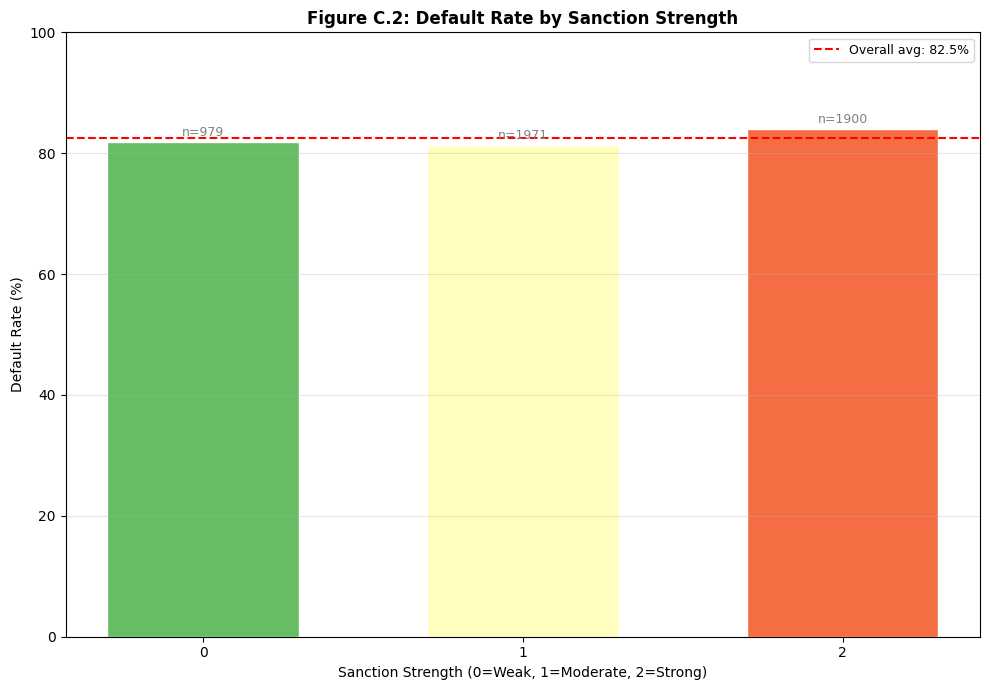

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Default Rate by Group Cohesion Score
grp_col = 'Sanction_Strength_Encoded'
x_label = 'Sanction Strength (0=Weak, 1=Moderate, 2=Strong)'
title_str = 'Figure C.2: Default Rate by Sanction Strength'


if grp_col:
    plt.figure(figsize=(10, 7))

    cohesion_stats = df.groupby(grp_col)['Loan_Default_Status'].agg(['mean', 'count']).reset_index()
    cohesion_stats.columns = [grp_col, 'default_rate', 'count']
    cohesion_stats['default_rate_pct'] = cohesion_stats['default_rate'] * 100

    bar_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cohesion_stats)))
    bars = plt.bar(cohesion_stats[grp_col].astype(str),
                   cohesion_stats['default_rate_pct'],
                   color=bar_colors, edgecolor='white', width=0.6)

    # Annotate bars with count
    for bar, n in zip(bars, cohesion_stats['count']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'n={n}', ha='center', va='bottom', fontsize=9, color='gray')

    plt.xlabel(x_label, fontsize=10)
    plt.ylabel('Default Rate (%)', fontsize=10)
    plt.title(title_str, fontsize=12, fontweight='bold')
    plt.ylim(0, 100)
    plt.axhline(df['Loan_Default_Status'].mean()*100, color='red', linestyle='--',
                lw=1.5, label=f"Overall avg: {df['Loan_Default_Status'].mean()*100:.1f}%")
    plt.legend(fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_C2_default_rate_cohesion.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print("Neither 'Group_Cohesion_Score' nor 'Sanction_Strength_Encoded' found in dataframe")